# Impact Analysis on AB1104 for Santa Cruz County
We have identified the following components as of importance to understanding how recent policy changes have affected local businesses.

## Economic Impact Analysis
Quantify potential penalties avoided, project delays, and savings retained through AB 1104 reforms.
Estimate the cost to comply with public works registration and reporting requirements.
Estimate total lost investment and increased electricity costs for businesses unable to go solar due to compliance barriers.

## Environmental Cost Analysis
Show benefits in tangible environmental metrics (e.g., carbon emission reductions, local energy resilience).

# Santa Cruz Commercial & Industrial Projects

In order to understand policy impacts we need to take a closer look at how much capacity has been added in Santa Cruz County and the size of a typical commercial/industrial project. We use data from [California DG Stats](https://www.californiadgstats.ca.gov/downloads/) for that. The only IOU operating in the region is PG&E, so we'll focus on the PG&E data.

Below we'll import essential packages and read the data.

In [1]:
import datetime
import glob
import numpy as np
import numpy_financial as npf
import os
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import sys

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import data_analysis as data_analysis
import data_visualization as data_vis

import plotly.io as pio
from plotly.offline import init_notebook_mode

pio.renderers.default = "notebook_connected"
init_notebook_mode(connected=True)

Set data directory containing applications csv files and archive files from DGStats in subdirectories.
DGStats data is released every few weeks/months. The folder 'applications_20251231' contains data from all years 2021-25.

In [2]:
data_dir = '/Users/jenny.folkesson/Data/solar/'
dgstats_dir = os.path.join(data_dir, 'applications_20251231/')
archive_dir = os.path.join(data_dir, 'Interconnection_Applications_Dataset_2024-12-31/')

Load applications from the past 5 years, which for this data set are the complete calendar years 2021-25. We will also merge with archival data in case we need to look further back in history.

In [3]:
import importlib
importlib.reload(data_analysis)
df_total = data_analysis.read_stored_data(dgstats_dir, "dgstats_preprocessed_data.csv", archive_dir)

Reading existing file:  /Users/jenny.folkesson/Data/solar/applications_20251231/dgstats_preprocessed_data.csv


## Commercial and Industrial Projects in Santa Cruz County

Select only commercial and industrical applications in Santa Cruz county from the dataframe.

In [4]:
df_scci = df_total.copy()
df_scci = df_scci[df_scci['Service County'].str.lower() == 'santa cruz']
df_scci = df_scci[(df_scci['Customer Sector'] == 'Commercial') | (df_scci['Customer Sector'] == 'Industrial')]

In [5]:
# Inspect data
df_scci

,IOU,Application Status,Utility,Service City,Service County,Technology Type,System Size DC,System Size AC,Storage Capacity (kWh),Storage Size (kW AC),...,Decommissioned Date,Self Installer,Installer Name,Third Party Owned,Third Party Name,Pace Financed,Total System Cost,Cost/Watt,NEM Tariff,Interconnection Program
548276,PGE,Interconnected,PGE,SANTA CRUZ,SANTA CRUZ,"Photovoltaic, External Inverter",352.440,346.627,0.0,0.0,...,NaT,No,Enact Systems Inc,No,NaN,No,867193.0000,2.501804,2.0,NEMMT
548964,PGE,Interconnected,PGE,WATSONVILLE,SANTA CRUZ,"Photovoltaic, External Inverter",46.368,45.468,0.0,0.0,...,NaT,No,BLACK & VEATCH CONSTRUCTION INC,No,NaN,No,15000.0000,0.329902,2.0,EXPNEM
549543,PGE,Interconnected,PGE,SANTA CRUZ,SANTA CRUZ,"Photovoltaic, External Inverter",16.104,15.943,0.0,0.0,...,NaT,No,JUST LEAKS INCORPORATED,No,NaN,No,57338.0000,3.596437,2.0,SNEM
550281,PGE,Interconnected,PGE,SANTA CRUZ,SANTA CRUZ,"Photovoltaic, External Inverter",47.267,46.536,0.0,0.0,...,NaT,No,SLINGSHOT POWER INC,No,NaN,NaN,0.0001,0.000000,2.0,EXPNEM
552335,PGE,Interconnected,PGE,SCOTTS VALLEY,SANTA CRUZ,"Photovoltaic, External Inverter",187.880,184.869,0.0,0.0,...,NaT,No,MYNT SYSTEMS INC,No,NaN,No,440787.0000,2.384320,2.0,EXPNEM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2091815,PGE,Interconnected,PGE,WATSONVILLE,SANTA CRUZ,Photovoltaic,17.520,17.006,0.0,0.0,...,NaT,No,SOLAR SYMPHONY CONSTRUCTION INC,No,NaN,No,51219.0000,3.011819,2.0,SNEM
2093551,PGE,Interconnected,PGE,SANTA CRUZ,SANTA CRUZ,Photovoltaic,20.020,19.438,0.0,0.0,...,NaT,No,ALLTERRA SOLAR,No,NaN,No,86700.0000,4.460335,2.0,SNEM
2094780,PGE,Interconnected,PGE,SCOTTS VALLEY,SANTA CRUZ,Photovoltaic,25.666,25.377,0.0,0.0,...,NaT,No,1ST LIGHT ENERGY INC,No,NaN,No,71422.0000,2.814438,2.0,SNEM
2107673,PGE,Interconnected,PGE,SCOTTS VALLEY,SANTA CRUZ,Photovoltaic,11.328,10.982,0.0,0.0,...,NaT,No,ALLTERRA SOLAR,No,NaN,No,65000.0000,5.918776,2.0,SNEM


## DGStats Data Gap

DGStats provides a delayed snapshot of the solar market because it only publishes projects that have been issued Permission to Operate (PTO) by the utility. This delay is particularly significant for commercial and industrial solar projects, which typically have longer interconnection and construction timelines than residential systems.

In April of 2025, we received numbers on application volume directly from PG&E. If we compare the numbers we received directly from PG&E with the corresponding numbers from California DG Stats, this can give us an estimate of how much data we're missing due to the lack of reporting pending applications in the California DG Stats data set.

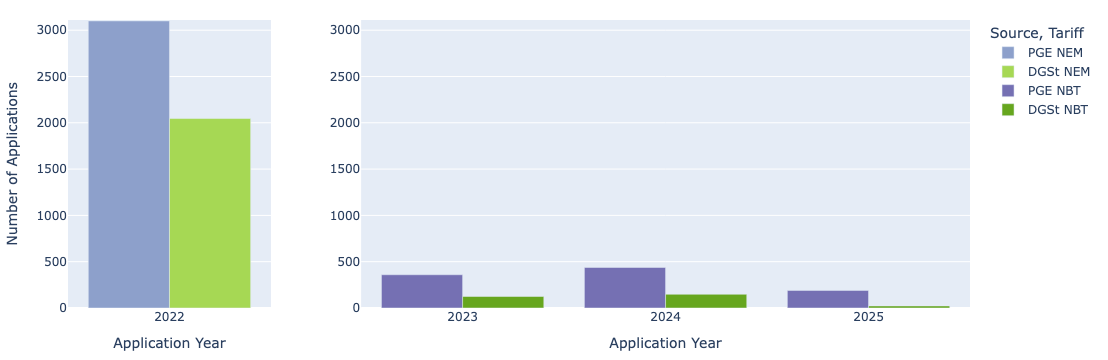

In [6]:
fig = data_vis.dgstats_vs_pge_bargraph(df_total)
fig.show()

# Write figure
fig.write_image(os.path.join(data_dir, "DGStats_vs_PGE.png"), scale=5)
fig.write_html(os.path.join(data_dir, "DGStats_vs_PGE.html"),
               include_plotlyjs='cdn',
               full_html=False,
               config={"responsive": True}
)

PG&E decline in applications after 2022 is measured by comparing its 2024 application number by the number from 2022. The years 2023-25 only lists NBT applications, and 2023 does not reflect a full calendar year of applications since the NBT deadline was in April of that year.

In [7]:
# PGE application decrease after 2022
app_change = (438 - 3100) / 3100 * 100
print("Application volume change: {:.1f}%".format(app_change))

Application volume change: -85.9%


## System Sizes in the years 2021-25

Plot histogram of system sizes applied for in the last five years, and compute median size for Santa Cruz County.

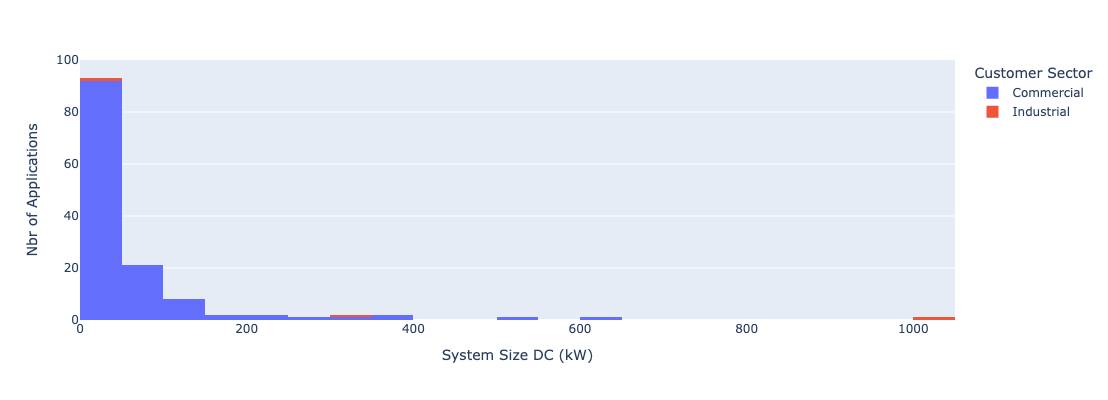

In [8]:
df = df_scci.copy()
df['Year'] = df['App Approved Date'].dt.year
df = df[df['Year'] >= 2021]
fig = px.histogram(df, x='System Size DC', color='Customer Sector')

fig.update_layout(
    autosize=False,
    width=800,
    height=400,
    font=dict(size=12),
    xaxis_title='System Size DC (kW)',
    yaxis_title='Nbr of Applications',
)
fig.update_yaxes(
    range=[0, 100],
)
fig.show()

# Write figure
fig.write_image(os.path.join(data_dir, "SC_system_histogram.png"), scale=5)
fig.write_html(os.path.join(data_dir, "SC_system_histogram.html"),
               include_plotlyjs='cdn',
               full_html=False,
               config={"responsive": True}
)

In [9]:
# Application sizes
nbr_app = df.shape[0]
print("Percentage of projects < 50 kW: {:.1f}%".format(93 / nbr_app * 100))
print("Percentage of projects < 100 kW: {:.1f}%".format( (93 + 21) / nbr_app * 100))

Percentage of projects < 50 kW: 69.4%
Percentage of projects < 100 kW: 85.1%


In [10]:
# Median application data
df = df_scci.copy()
df = df[df['App Approved Date'].dt.year >= 2021]
# Median capacity
print("Median capacity DC: {} kW".format(df['System Size DC'].median()))

# Median tilt
df['Tilt'] = pd.to_numeric(df['Tilt'], errors='coerce')
print("Median tilt: {} degrees".format(df['Tilt'].median()))

# Median azimuth
df['Azimuth'] = pd.to_numeric(df['Azimuth'], errors='coerce')
print("Median azimuth: {} degrees".format(df['Azimuth'].median()))

Median capacity DC: 29.9085 kW
Median tilt: 18.0 degrees
Median azimuth: 180.0 degrees


## Solar Application Processing Times

Below is a graph showing median commercial and industrial solar application times in Santa Cruz County, divided by color into time from
application received until deemed complete by the utility (Rec-Comp) and from time application is complete until
permission to operate is issued (Comp-Appr).

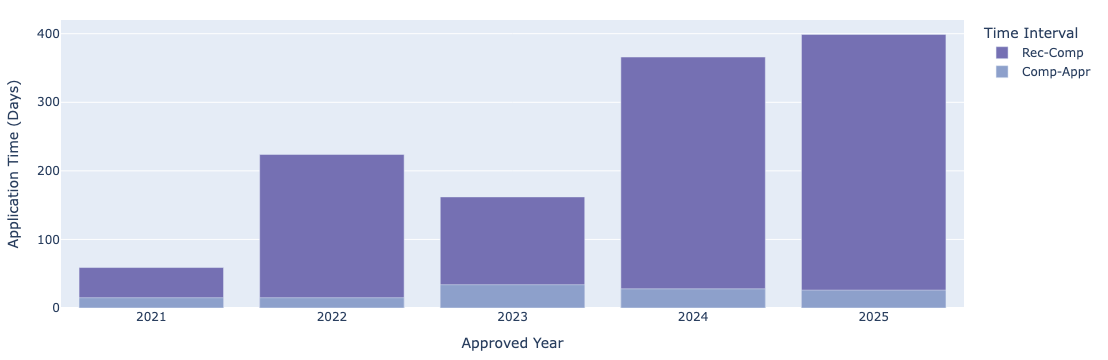

In [11]:
fig = data_vis.application_time_bargraph(df_scci)
fig.show()

# Write figure
fig.write_image(os.path.join(data_dir, "SC_application_time.png"), scale=5)
fig.write_html(os.path.join(data_dir, "SC_application_time.html"),
               include_plotlyjs='cdn',
               full_html=False,
               config={"responsive": True}
)

## Total Added Capacity in 2021-25

Visualize data applications in terms of applied for capacity per year with NBT and AB 2143 deadlines annotated.

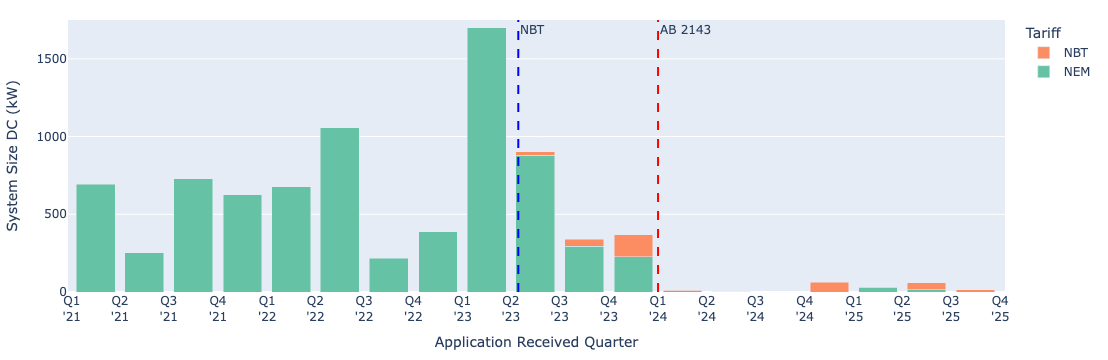

In [12]:
import importlib
importlib.reload(data_vis)
fig = data_vis.commercial_capacity_per_year(df_scci, y_range=1750)
fig.show()

# Write figure
fig.write_image(os.path.join(data_dir, "SC_capacity.png"), scale=5)
fig.write_html(os.path.join(data_dir, "SC_capacity.html"),
               include_plotlyjs='cdn',
               full_html=False,
               config={"responsive": True}
)

Find number of applications in 2024, and compute median annual number of applications for the 10 years prior to the volatility starting with the NBT deadline, so years 2013-22.

In [13]:
df = df_scci.copy()
df = df[['App Received Date', 'System Size DC']]
df = df.set_index('App Received Date').rename_axis(None)
df['Nbr Applications'] = 1
df = df.groupby(df.index.year).sum()
df = df[df.index > 2012]
df

,System Size DC,Nbr Applications
2013,1344.600,28
2014,2927.806,17
2015,301.077,9
2016,2005.947,27
2017,2316.343,23
2018,909.916,18
2019,1300.814,20
2020,1213.766,23
2021,2302.869,34
2022,2338.809,24


In [14]:
# Median and mean application volume in the years 2013-22
df = df[df.index <= 2022]
print("Mean number of applications: ", df['Nbr Applications'].mean())
print("Median number of applications: ", df['Nbr Applications'].median())

Mean number of applications:  22.3
Median number of applications:  23.0


Applying the observed DGStats undercount rate of approximately two-thirds suggests a maximum of roughly 12
applications in 2024 — eleven fewer than the historical median. Alternatively, using Santa Cruz County–specific
processing timelines (see Figure 3), we will assume that approximately half of the 2024 applications have been
processed so far, in which case there would be approximately eight total applications for 2024 — representing a
reduction of 15 projects compared to the historical median. Taken together, these approaches indicate an estimated reduction of 12 to 15 commercial and industrial solar
projects in Santa Cruz County in 2024.

## Electricity Price

Compare electricity prices from PG&E to the California and US averages. We can get bundled system average rates from [CPUC Historical Electric Cost Data](https://www.cpuc.ca.gov/industries-and-topics/electrical-energy/electric-costs/historical-electric-cost-data) and we can put PG&E rates in perspective by comparing them with the California and US averages using data from the [US Energy Information Administration's Electricity Data Browser](https://www.eia.gov/electricity/data/browser/).
At the time of writing (March 4, 2026), CPUC had not yet updated their Historical Electric Cost Data to include 2025, so we'll look at prices up until 2024.

Inflation data is collected from [FRED](https://fred.stlouisfed.org/series/CPIAUCNS#).

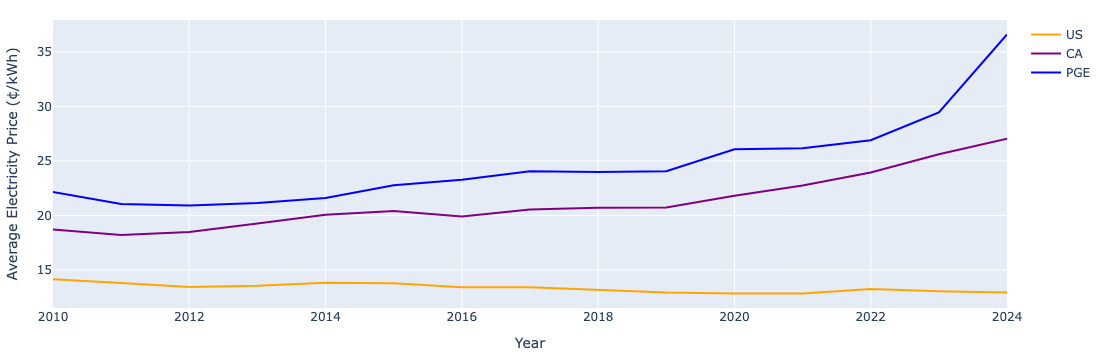

In [15]:
df = data_analysis.compile_electricity_rates(data_dir, nominal_year=2024)
fig = data_vis.electricity_rates_scatter(df, max_year=2024)
fig.show()

# Write figure
fig.write_image(os.path.join(data_dir, "electricity_rates.png"), scale=5)
fig.write_html(os.path.join(data_dir, "electricity_rates.html"), 
               include_plotlyjs='cdn',
               full_html=False,
               config={"responsive": True}
)

In [16]:
df = df.set_index(df['Year'])
df['CA Comm'] = pd.to_numeric(df['CA Comm'], downcast='float', errors='coerce')
df['US Comm'] = pd.to_numeric(df['US Comm'], downcast='float', errors='coerce')

incr = (df.loc[2025]['US Comm']/df.loc[2020]['US Comm']) ** (1 / 5)
print("US commercial rate increase: {:.2f}%".format((incr - 1) * 100))
incr5 = (df.loc[2025]['US Comm']/df.loc[2020]['US Comm'] - 1) * 100
print("Over 5 years: {:.1f}%".format(incr5))
incr = (df.loc[2025]['CA Comm']/df.loc[2020]['CA Comm']) ** (1 / 5)
print("CA commercial rate increase: {:.2f}%".format((incr - 1) * 100))
incr5 = (df.loc[2025]['CA Comm']/df.loc[2020]['CA Comm'] - 1) * 100
print("Over 5 years: {:.1f}%".format(incr5))

US commercial rate increase: 4.84%
Over 5 years: 26.6%
CA commercial rate increase: 8.50%
Over 5 years: 50.4%


## Solar Installation Cost Savings

From the the median values of capacity, tilt and azimuth of a commercial solar project, we can estimate what a typical commercial solar system outputs in a year using the [NREL PV Watts Calculator](https://pvwatts.nlr.gov/pvwatts.php).In order to estimate lost opportunity cost, we will start by estimating how much a business would save in electricity cost had they installed an median sized solar project (29.9 kW). For Santa Cruz coordinates and the standard loss estimate we get an estimated output of 45 MWh per year, with a range of 43.3 to 45.8 MWh. 

PG&E commercial bundled average rates can be found [here](https://www.pge.com/tariffs/en/rate-information/electric-rates.html#accordion-a84c67dc1e-item-c850e1a108). We base our electricity price estimates on aggregates of the Commercial/General Service small to medium sized business (B-1, B-6, B-10) rates. In 2024, the prices ranged from \\$0.37/kWh to \\$0.45/kWh, which we have reflected, slightly conservatively, in our estimated parameters.

We will estimate lower bound, baseline, and upper bound cost and savings estimates for a typical Santa Cruz commercial & industrial system.
Below are the parameters we will use for the three scenarios.

| Input | Lower Bound | Baseline | Upper Bound |
| :- | :-: | :-: | :-: |
| System Price (\\$/kW) | 4,000 | 3,500 | 3,000 |
| Annual Production (kWh) | 43,300 | 45,000 | 45,800 |
| Annual System Degradation (%) | 0.6 | 0.5 | 0.4 |
| Electricity Price (\\$/kWh) | 0.35 | 0.39 | 0.43 |
| Annual Rate Increase (%) | 2.75 | 3.5 | 6 |

### Lower Bound
Cost forecast assuming constant percentage price increase and system degradation each year.

In [17]:
df = data_analysis.cost_forecast(nbr_years=25, production=43300, price=0.35, price_increase=2.75, degradation=0.6)
df[['Production (kWh)', 'Cumulative Savings ($)']]

,Production (kWh),Cumulative Savings ($)
1,"43,300","15,155"
2,"43,040","30,633"
3,"42,782","46,442"
4,"42,525","62,588"
5,"42,270","79,078"
6,"42,016","95,920"
7,"41,764","113,122"
8,"41,514","130,690"
9,"41,265","148,633"
10,"41,017","166,959"


Upfront cost of the solar installation

In [18]:
cost = 29.9 * 4000
print("Upfront Cost: ${:.0f}".format(cost))

Upfront Cost: $119600


Total savings over solar system lifetime (cumulative savings minus upfront cost)

In [19]:
cumsav = df.iloc[-1]['Cumulative Savings ($)']
cumsav = float(cumsav.replace(",", ""))
print("Cumulative Savings: ${:.0f}".format(cumsav - cost))

Cumulative Savings: $374182


IRR - Internal Rate of Return

In [20]:
cash_flow = [-cost] + list(df['Annual Savings ($)'])
irr = npf.irr(cash_flow)
print("IRR: {:.1f}%".format(irr*100))

IRR: 14.0%


### Baseline

In [21]:
importlib.reload(data_analysis)
df = data_analysis.cost_forecast(nbr_years=25, production=45000, price=0.39, price_increase=3.5, degradation=0.5)
df[['Production (kWh)', 'Cumulative Savings ($)']]
for row in df.iterrows():
    print(str(str(row[0]) + ' & ' + row[1]['Production (kWh)'] + ' & '  + row[1]['Rate ($/kWh)'] + ' & ' + row[1]['Cumulative Savings ($)']  + ' ' + chr(92) + chr(92)))

1 & 45,000 & 0.39 & 17,550 \\
2 & 44,775 & 0.4 & 35,623 \\
3 & 44,551 & 0.42 & 54,236 \\
4 & 44,328 & 0.43 & 73,403 \\
5 & 44,107 & 0.45 & 93,143 \\
6 & 43,886 & 0.46 & 113,471 \\
7 & 43,667 & 0.48 & 134,405 \\
8 & 43,448 & 0.5 & 155,964 \\
9 & 43,231 & 0.51 & 178,165 \\
10 & 43,015 & 0.53 & 201,029 \\
11 & 42,800 & 0.55 & 224,575 \\
12 & 42,586 & 0.57 & 248,823 \\
13 & 42,373 & 0.59 & 273,794 \\
14 & 42,161 & 0.61 & 299,510 \\
15 & 41,950 & 0.63 & 325,993 \\
16 & 41,741 & 0.65 & 353,265 \\
17 & 41,532 & 0.68 & 381,351 \\
18 & 41,324 & 0.7 & 410,275 \\
19 & 41,118 & 0.72 & 440,062 \\
20 & 40,912 & 0.75 & 470,737 \\
21 & 40,707 & 0.78 & 502,326 \\
22 & 40,504 & 0.8 & 534,858 \\
23 & 40,301 & 0.83 & 568,360 \\
24 & 40,100 & 0.86 & 602,862 \\
25 & 39,899 & 0.89 & 638,392 \\


Upfront cost of the solar installation

In [22]:
cost = 29.9 * 3500
print("Upfront Cost: ${:.0f}".format(cost))

Upfront Cost: $104650


Total savings over solar system lifetime (cumulative savings minus upfront cost)

In [23]:
cumsav = df.iloc[-1]['Cumulative Savings ($)']
cumsav = float(cumsav.replace(",", ""))
print("Cumulative Savings: ${:.0f}".format(cumsav - cost))

Cumulative Savings: $533742


IRR

In [24]:
cash_flow = [-cost] + list(df['Annual Savings ($)'])
irr = npf.irr(cash_flow)
print("IRR: {:.1f}%".format(irr*100))

IRR: 19.3%


In [25]:
# 1-3 months of first year electicity savings
print("1-3 months savings: ${:.0f} - ${:.0f}".format(17550/12, 17550/12 * 3))

1-3 months savings: $1462 - $4388


### Upper Bound

In [26]:
df = data_analysis.cost_forecast(nbr_years=25, production=45800, price=0.43, price_increase=6, degradation=0.4)
df[['Production (kWh)', 'Cumulative Savings ($)']]

,Production (kWh),Cumulative Savings ($)
1,"45,800","19,694"
2,"45,617","40,486"
3,"45,434","62,438"
4,"45,253","85,613"
5,"45,072","110,081"
6,"44,891","135,913"
7,"44,712","163,186"
8,"44,533","191,979"
9,"44,355","222,378"
10,"44,177","254,471"


Upfront cost of the solar installation

In [27]:
cost = 29.9 * 3000
print("Upfront Cost: ${:.0f}".format(cost))

Upfront Cost: $89700


Total savings over solar system lifetime (cumulative savings minus upfront cost)

In [28]:
cumsav = df.iloc[-1]['Cumulative Savings ($)']
cumsav = float(cumsav.replace(",", ""))
print("Cumulative Savings: ${:.0f}".format(cumsav - cost))

Cumulative Savings: $928435


IRR

In [29]:
cash_flow = [-cost] + list(df['Annual Savings ($)'])
irr = npf.irr(cash_flow)
print("IRR: {:.1f}%".format(irr*100))

IRR: 27.3%


### Lost Opportunity Cost:

Using the estimated reduction of 11-15 commercial solar installations in Santa Cruz County in 2024, and assuming median-sized systems, estimate the resulting lost electricity cost savings for business owners in Santa Cruz County.

In [30]:
# Savings for baseline year 1 * [11, 15]
print("Total savings in SC: ${:.0f} - ${:.0f}".format(17550 * 11, 17550 * 15))

Total savings in SC: $193050 - $263250


In [31]:
# Over 25 years
print("Total savings in SC: ${:.0f} - ${:.0f}".format(17550 * 11 * 25, 17550 * 15 * 25))

Total savings in SC: $4826250 - $6581250


## Environmental Impact

How much of pg&e electricity comes from CO2 sources?
According to PG&E, their base plan emits 16 lbs/MWh of CO2e, which is 16*0.45359237 = 7.26 kg/MWh.
[Power Contents Label Data.](https://www.energy.ca.gov/programs-and-topics/programs/power-source-disclosure-program/power-content-label/annual-power-5)


This is really low compared to the CA utility average, which is 359 lbs CO2e/MWh
which would cause 6.8 metric tonnes of CO2e emissions per year.

In [32]:
# Emission reduction from typical SC solar installation (PG&E)
print("PG&E Emission reduction: {:.1f} kg CO2e/year.".format(16 * 0.45359237 * 45))

PG&E Emission reduction: 326.6 kg CO2e/year.


In [33]:
print("CA Average Emission reduction: {:.1f} kg CO2e/year.".format(359 * 0.45359237 * 45))

CA Average Emission reduction: 7327.8 kg CO2e/year.


In [34]:
# 11-15 Santa Cruz commercial solar installations
print("PG&E Emission reduction for 11-15 installations: {:.0f}-{:.0f} kg CO2e/year.".format(16 * 0.45359237 * 45 * 11, 16 * 0.45359237 * 45 * 15))

PG&E Emission reduction for 11-15 installations: 3592-4899 kg CO2e/year.


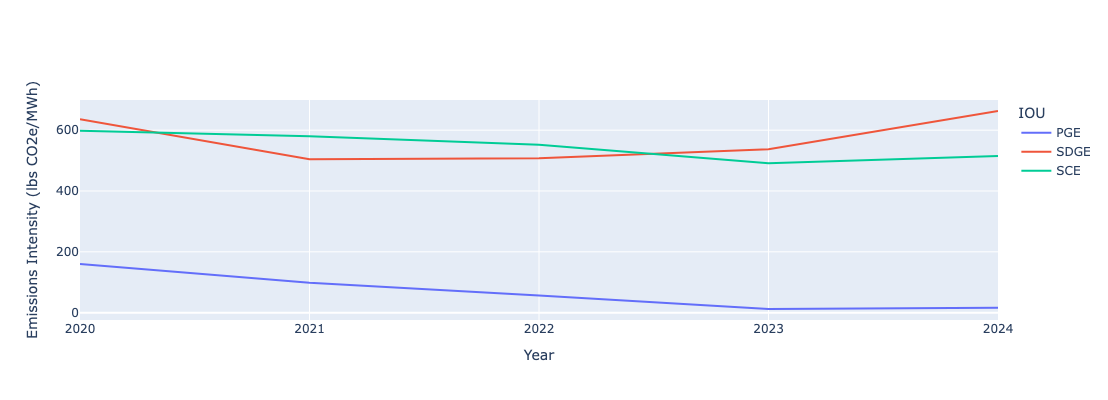

In [35]:
# Data collected from the power contents label data link above for the three main CA IOUs
# PG&E Greenhouse Gas Emissions Intensity (lbs CO2e/MWh)
data = {'Year': [2024, 2023, 2022, 2021, 2020],
        'PGE': [16, 12, 56, 98, 160],
        'SDGE': [663, 537, 508, 504, 636],
        'SCE': [515, 491, 552, 580, 598]}
df_co2 = pd.DataFrame(data)
df_co2

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=df_co2['Year'],
        y=df_co2['PGE'],
        name='PGE',
        mode='lines',
    ),
)
fig.add_trace(
    go.Scatter(
        x=df_co2['Year'],
        y=df_co2['SDGE'],
        name='SDGE',
        mode='lines',
    ),
)
fig.add_trace(
    go.Scatter(
        x=df_co2['Year'],
        y=df_co2['SCE'],
        name='SCE',
        mode='lines',
    ),
)
fig.update_layout(
    yaxis_title='Emissions Intensity (lbs CO2e/MWh)',
    xaxis_title='Year',
    width=800,
    height=400,
    font=dict(size=12),
    xaxis=dict(tickvals=df_co2['Year']),
    legend={'title': 'IOU'},
    hovermode="x unified",
)
fig.update_traces(hovertemplate=None)
fig.show()

# Write figure
fig.write_image(os.path.join(data_dir, "emissions_intensity.png"), scale=5)
fig.write_html(os.path.join(data_dir, "emissions_intensity.html"), 
               include_plotlyjs='cdn',
               full_html=False,
               config={"responsive": True}
)